## Objective
Predict whether a vendor invoice should be **flagged for manual approval** based on abnormal freight, pricing, or delivery patterns — in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

## Business Problem
- Manual invoice review is time-consuming and does not scale with transaction volume
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks
- An automated flagging system enables finance teams to focus on **high-risk invoices** while allowing low-risk ones to be processed automatically

## Pipeline Overview
```
Load CSVs → Aggregate → Merge → Feature Engineering → Rule-based Labeling → Model Training → Evaluate → Save
```

## Data Sources
| File | Description |
|---|---|
| `vendor_invoice.csv` | Core invoice data — one row per PO per vendor |
| `purchases.csv` | Line-item purchase orders — aggregated to PO level |
| `purchase_prices.csv` | Catalog reference prices per vendor |
| `begin_inventory.csv` | Stock levels at start of period |
| `end_inventory.csv` | Stock levels at end of period |

---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

---
## 2. Load Data

In [2]:
purchases       = pd.read_csv('../data/purchases.csv')
purchase_prices = pd.read_csv('../data/purchase_prices.csv')
vendor_invoice  = pd.read_csv('../data/vendor_invoice.csv')
begin_inv       = pd.read_csv('../data/begin_inventory.csv')
end_inv         = pd.read_csv('../data/end_inventory.csv')

print(f"purchases       : {purchases.shape}")
print(f"purchase_prices : {purchase_prices.shape}")
print(f"vendor_invoice  : {vendor_invoice.shape}")
print(f"begin_inv       : {begin_inv.shape}")
print(f"end_inv         : {end_inv.shape}")

purchases       : (2372474, 16)
purchase_prices : (12261, 9)
vendor_invoice  : (5543, 10)
begin_inv       : (206529, 9)
end_inv         : (224489, 9)


---
## 3. Aggregate Purchases

`purchases.csv` has **many rows per PO** (one per product line item), but `vendor_invoice` has **one row per PO**. 

We must aggregate purchases to PO level before merging — otherwise we get a row explosion (one invoice matching thousands of product lines).

In [3]:
purchases_agg = purchases.groupby(['PONumber', 'VendorNumber']).agg(
    Dollars_po    = ('Dollars', 'sum'),
    Quantity_po   = ('Quantity', 'sum'),
    PurchasePrice = ('PurchasePrice', 'mean')
).reset_index()

print(f"purchases_agg shape: {purchases_agg.shape}")
purchases_agg.head()

purchases_agg shape: (5543, 5)


,PONumber,VendorNumber,Dollars_po,Quantity_po,PurchasePrice
0,8106,480,137483.78,10100,14.336467
1,8107,90046,348.72,24,14.530000
2,8108,1392,60281.13,8466,7.036120
3,8109,1590,14298.09,2246,6.675970
4,8110,3252,56493.23,8086,7.160858


---
## 4. Merge Tables

### 4a. vendor_invoice + purchases_agg
Join on `PONumber + VendorNumber` — this links each invoice to what was agreed in the PO.

In [4]:
df = vendor_invoice.merge(
    purchases_agg,
    on=['PONumber', 'VendorNumber'],
    how='left'
)

df = df.rename(columns={
    'Quantity' : 'Quantity_inv',
    'Dollars'  : 'Dollars_inv'
})

print(f"After merge: {df.shape}")
df.head()

After merge: (5543, 13)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity_inv,Dollars_inv,Freight,Approval,Dollars_po,Quantity_po,PurchasePrice
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,214.26,6.0,35.710000
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,140.55,15.0,9.370000
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,106.60,5.0,21.320000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,137483.78,10100.0,14.336467
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,15527.25,1935.0,8.041461


### 4b. Add Vendor Catalog Price
We compute the average agreed price per vendor from `purchase_prices` and merge it in as a benchmark.

In [5]:
vendor_avg_price = purchase_prices.groupby('VendorNumber')['PurchasePrice'].mean().reset_index()
vendor_avg_price.columns = ['VendorNumber', 'PurchasePrice_catalog']

df = df.merge(vendor_avg_price, on='VendorNumber', how='left')

print(f"Final df shape: {df.shape}")
print("Columns:", df.columns.tolist())

Final df shape: (5543, 14)
Columns: ['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity_inv', 'Dollars_inv', 'Freight', 'Approval', 'Dollars_po', 'Quantity_po', 'PurchasePrice', 'PurchasePrice_catalog']


---
## 5. Feature Engineering

We create features that capture **pricing anomalies**, **freight burden**, and **timing patterns**.

In [6]:
df['price_deviation'] = df['Dollars_inv'] - df['Dollars_po']
df['price_ratio']     = df['Dollars_inv'] / (df['Dollars_po'] + 1)
df['freight_ratio']   = df['Freight'] / (df['Dollars_inv'] + 1)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['PODate']      = pd.to_datetime(df['PODate'])
df['PayDate']     = pd.to_datetime(df['PayDate'])

df['invoice_delay_days'] = (df['InvoiceDate'] - df['PODate']).dt.days
df['payment_delay_days'] = (df['PayDate'] - df['InvoiceDate']).dt.days

df['qty_mismatch'] = df['Quantity_inv'] - df['Quantity_po']

round(df[['price_deviation', 'price_ratio', 'freight_ratio',
          'invoice_delay_days', 'payment_delay_days', 'qty_mismatch']].describe(), 2)

,price_deviation,price_ratio,freight_ratio,invoice_delay_days,payment_delay_days,qty_mismatch
count,4207.0,4207.00,5543.00,5543.00,5543.00,4207.0
mean,-0.0,1.00,0.01,16.42,35.47,0.0
std,0.0,0.01,0.00,3.13,5.84,0.0
min,-0.0,0.81,0.00,9.00,23.00,0.0
25%,0.0,1.00,0.00,14.00,31.00,0.0
50%,0.0,1.00,0.00,16.00,35.00,0.0
75%,0.0,1.00,0.01,19.00,40.00,0.0
max,0.0,1.00,0.11,23.00,48.00,0.0


---
## 6. Exploratory Data Analysis

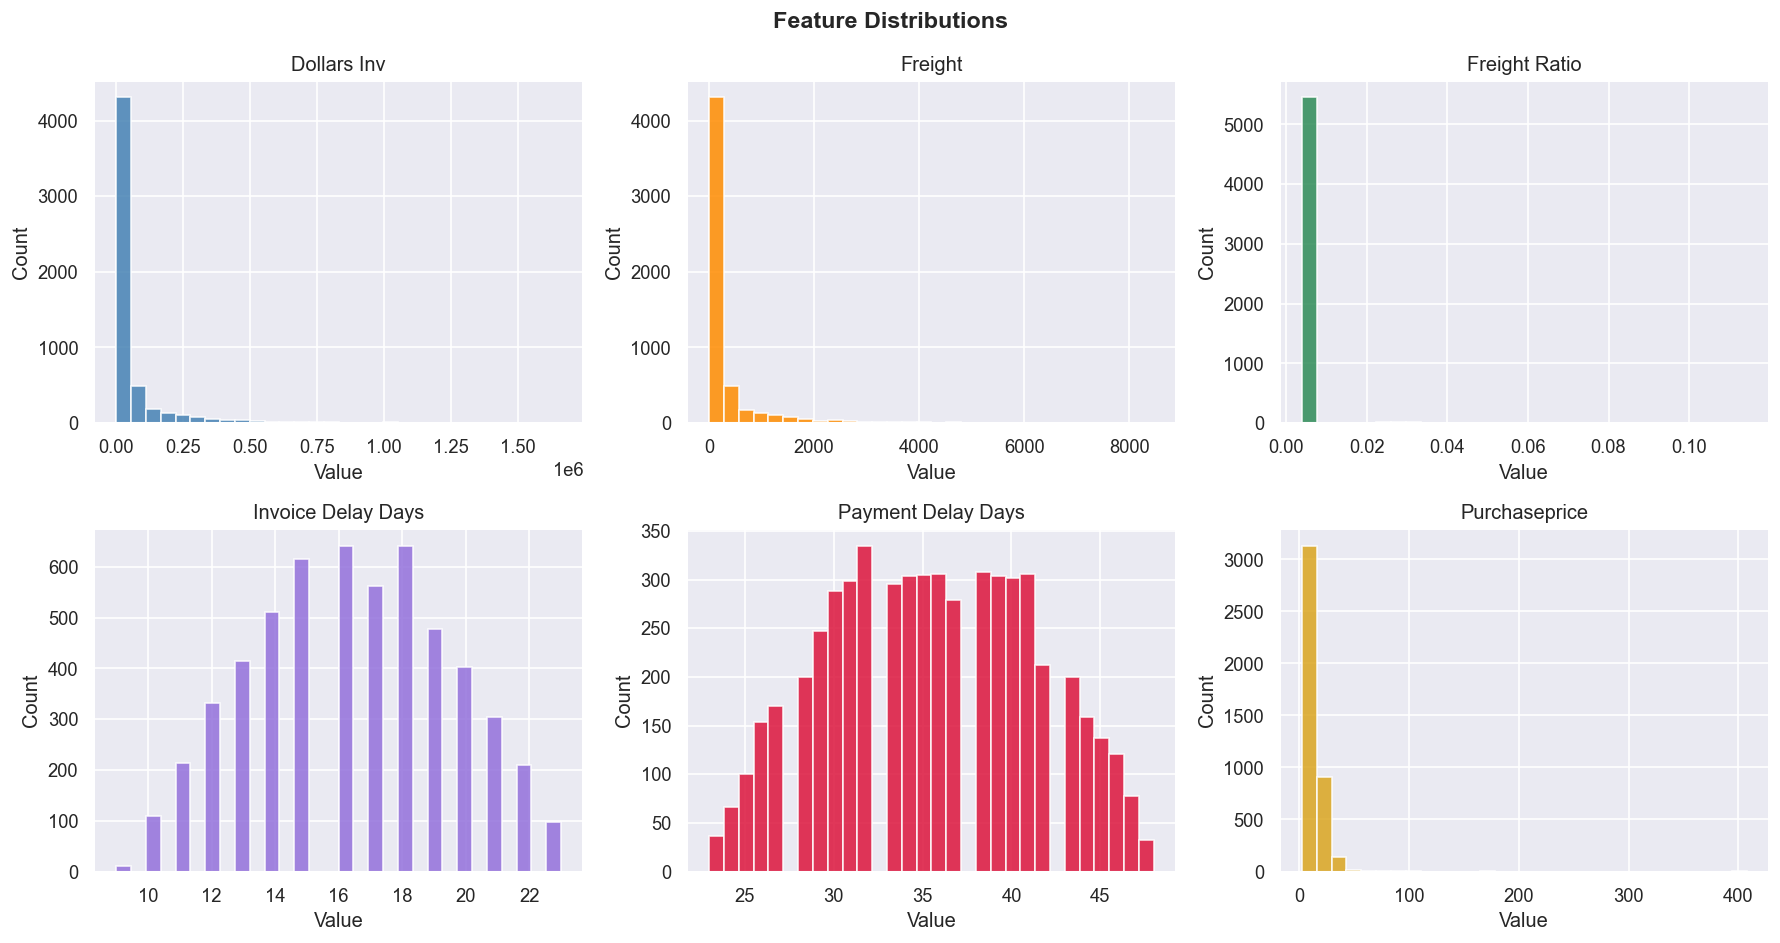

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_plot = ['Dollars_inv', 'Freight', 'freight_ratio',
                    'invoice_delay_days', 'payment_delay_days', 'PurchasePrice']
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson', 'goldenrod']

for ax, feat, color in zip(axes, features_to_plot, colors):
    ax.hist(df[feat].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

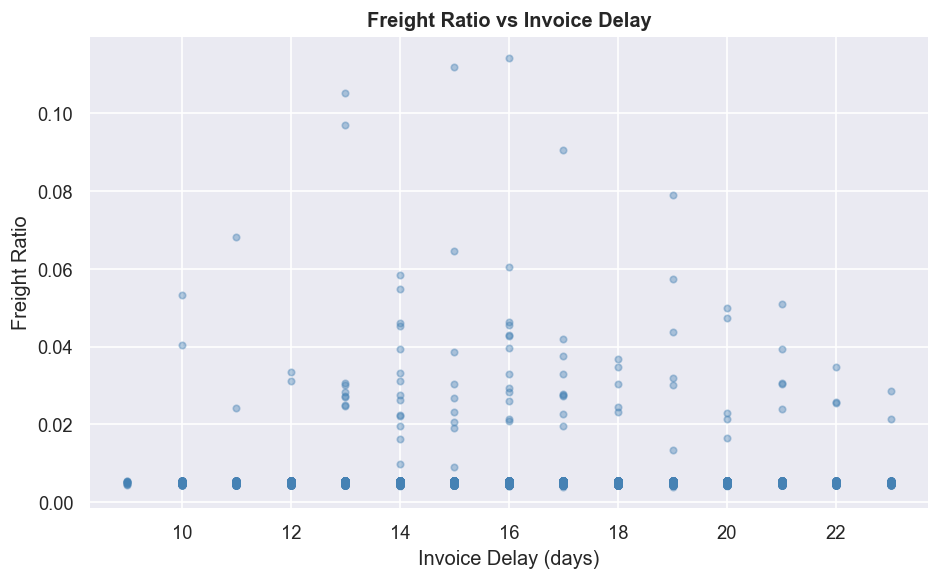

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['invoice_delay_days'], df['freight_ratio'],
            alpha=0.4, color='steelblue', s=15)
plt.xlabel('Invoice Delay (days)')
plt.ylabel('Freight Ratio')
plt.title('Freight Ratio vs Invoice Delay', fontweight='bold')
plt.tight_layout()
plt.show()

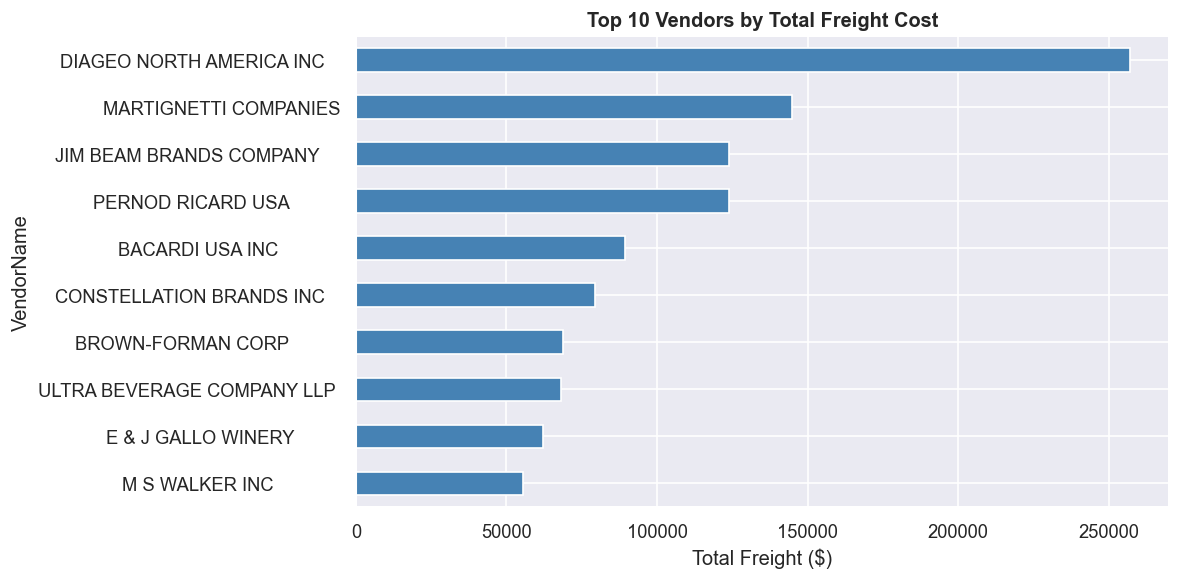

In [9]:
top_vendors = df.groupby('VendorName')['Freight'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_vendors.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Total Freight ($)')
plt.title('Top 10 Vendors by Total Freight Cost', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Create Target Variable — Rule-Based Flagging

Since the `Approval` column is empty, we **engineer the target** using business rules derived from the feature distributions above.

| Rule | Threshold | Rationale |
|---|---|---|
| `freight_ratio > 0.05` | > 75th percentile | Freight is an unusually large % of invoice |
| `invoice_delay_days > 19` | > 75th percentile | Invoice arrived very late after PO |
| `payment_delay_days > 40` | > 75th percentile | Payment took unusually long |

In [10]:
df['flag'] = (
    (df['freight_ratio']       > 0.05) |
    (df['invoice_delay_days']  > 19)   |
    (df['payment_delay_days']  > 40)
).astype(int)

print("Flag Distribution:")
print(df['flag'].value_counts())
print(f"\nFlagged: {df['flag'].mean()*100:.1f}%")

Flag Distribution:
flag
0    3334
1    2209
Name: count, dtype: int64

Flagged: 39.9%


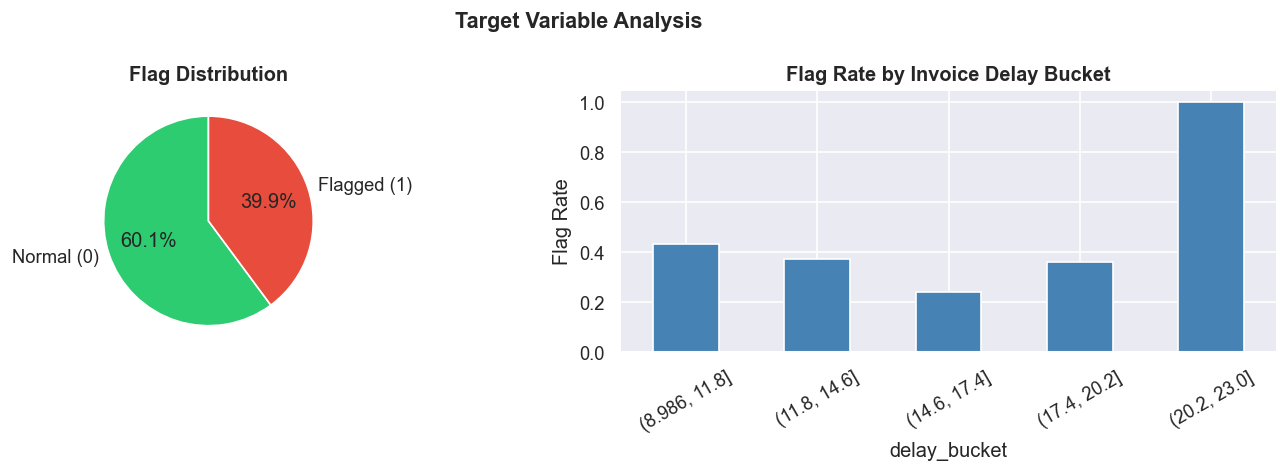

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['flag'].value_counts()
axes[0].pie(counts, labels=['Normal (0)', 'Flagged (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Flag Distribution', fontweight='bold')

# Flag rate by invoice delay bucket
df['delay_bucket'] = pd.cut(df['invoice_delay_days'], bins=5)
flag_by_delay = df.groupby('delay_bucket', observed=True)['flag'].mean()
flag_by_delay.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', rot=30)
axes[1].set_ylabel('Flag Rate')
axes[1].set_title('Flag Rate by Invoice Delay Bucket', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Prepare Features for ML

**Why use only raw features (not derived ones like `freight_ratio`)?**

The flag was created *using* `freight_ratio` and delay features — including them as model inputs would be **target leakage** (model learns the exact rules we wrote). Instead, we use the raw underlying signals and let the model discover the patterns itself.

In [12]:
features = ['Dollars_inv', 'Freight', 'Quantity_inv',
            'PurchasePrice', 'invoice_delay_days', 'payment_delay_days']

X = df[features].fillna(0)
y = df['flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("\nTrain flag distribution:")
print(y_train.value_counts())

Train: (4434, 6) | Test: (1109, 6)

Train flag distribution:
flag
0    2667
1    1767
Name: count, dtype: int64


---
## 9. Model Selection

**Why tree-based models only?**
> - Our features have threshold-based patterns (same as the rules we used to create flags)
> - Features are correlated — Logistic Regression assumes independence
> - Trees learn splits naturally, matching how our flag rules work

In [13]:
models = {
    'RandomForest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'          : XGBClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_hat), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_hat), 4)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,ROC-AUC
0,XGBoost,1.0000,1.0000
1,GradientBoosting,0.9982,0.9977
2,RandomForest,0.9973,0.9966


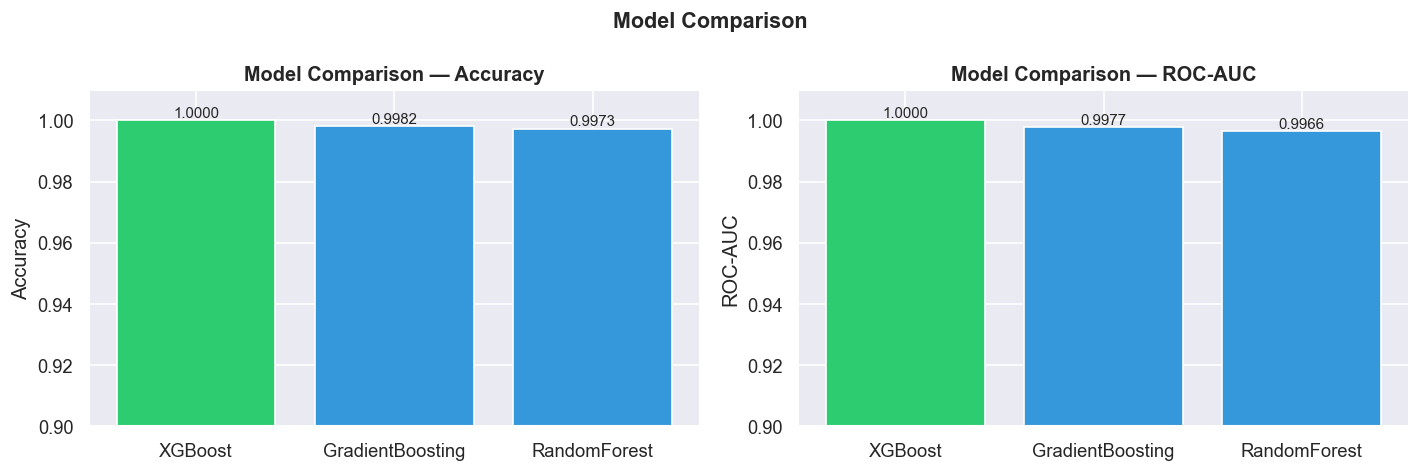

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]

axes[0].bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='white')
axes[0].set_ylim(0.9, 1.01)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Comparison — Accuracy', fontweight='bold')
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(results_df['Model'], results_df['ROC-AUC'], color=colors, edgecolor='white')
axes[1].set_ylim(0.9, 1.01)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Model Comparison — ROC-AUC', fontweight='bold')
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Best Model Evaluation — XGBoost

In [15]:
best_model = models['XGBoost']
y_pred     = best_model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Flagged']))

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       667
     Flagged       1.00      1.00      1.00       442

    accuracy                           1.00      1109
   macro avg       1.00      1.00      1.00      1109
weighted avg       1.00      1.00      1.00      1109



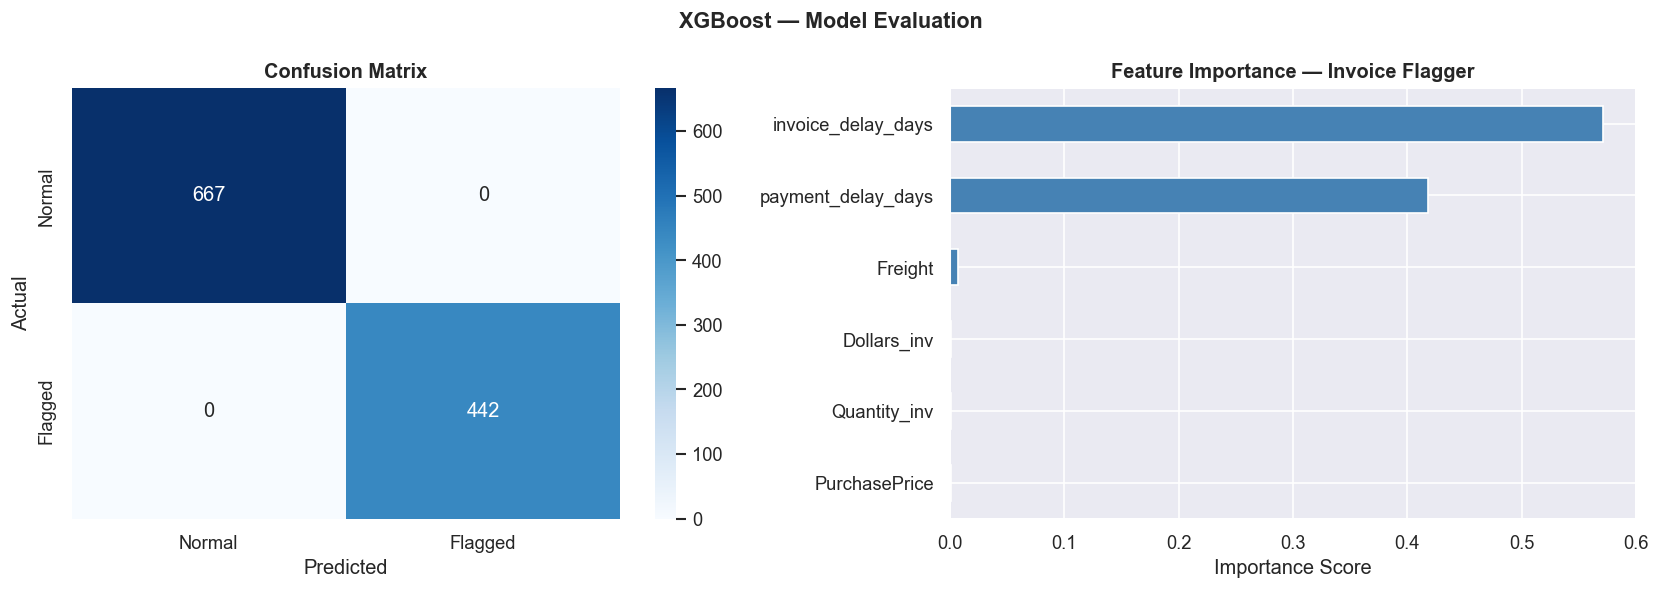

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Flagged'],
            yticklabels=['Normal', 'Flagged'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix', fontweight='bold')

feat_imp = pd.Series(best_model.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance — Invoice Flagger', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('XGBoost — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Key Finding:** `invoice_delay_days` and `payment_delay_days` are the strongest signals for flagging — timing anomalies matter more than dollar amounts in this dataset.

---
## 11. Save Model

In [17]:
import joblib

joblib.dump(best_model, '../models/invoice_flagger.pkl')

['../models/invoice_flagger.pkl']